pic

<p style="text-align: center; font-size: 28px;"><b>UCI Analysis</b></p>

summary

# Random Forests Project — Census Income (UCI)

Goal
- Use UCI Census data to predict whether a person’s annual income exceeds \$50{,}000 (binary classification).

Dataset
- Source (UCI ML Repository): https://archive.ics.uci.edu/ml/datasets/census+income
- The data has been preloaded into a DataFrame named `df`.

Features (examples)
- Numerical (continuous): `age`, `capital-gain`, `capital-loss`, `hours-per-week`
- Categorical (discrete): 
  - `workclass` ∈ {Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked}
  - `education` ∈ {Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool}
  - `race` ∈ {White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black}
  - `sex` ∈ {Female, Male}
  - `native country` (multiple categories)
- Target: `income` ∈ {`>50K`, `<=50K`}

Approach
1) Prepare data  
   - Handle missing values, trim whitespace, and encode categoricals (e.g., one-hot encoding).  
   - Consider class imbalance (often more `<=50K`): use stratified splits and evaluate with balanced metrics.

2) Model  
   - Train a `RandomForestClassifier` to predict `income`.  
   - Typical settings to start:
     - `n_estimators` (e.g., 200–500),
     - `max_features='sqrt'`,
     - `class_weight='balanced'` (if class imbalance hurts performance),
     - `random_state` for reproducibility.

3) Evaluation  
   - Hold-out or cross-validation.  
   - Report Accuracy, Precision, Recall, F1, and Confusion Matrix.  
   - Optionally AUC-ROC for threshold analysis.

4) Interpretation & Checks  
   - Inspect feature importances (diagnostic, not causal).  
   - Sanity-check gains/losses, hours, and education effects.

Outcome
- A robust baseline classifier that generalizes well on tabular data, offers reasonable interpretability via feature importances, and sets a benchmark for further tuning or alternative models (e.g., Gradient Boosting).


# Investigate the data

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import models from scikit learn module:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, RandomForestRegressor
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [111]:
col_names = ['age', 'workclass', 'fnlwgt','education', 'education-num', 
'marital-status', 'occupation', 'relationship', 'race', 'sex',
'capital-gain','capital-loss', 'hours-per-week','native-country', 'income']
df = pd.read_csv('data_folder/adult.data', header=None, names = col_names)

<p style="font-size: 20px;"><b>Task 1</b></p>  
We will build a random forest classifier to predict the income category. First, take a look at the distribution of income values – what percentage of samples have incomes less than 50k and greater than 50k?

In [112]:
df['income'].value_counts(normalize=True)

income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

<p style="font-size: 20px;"><b>Task 2</b></p>  
There’s a small problem with our data that is a little hard to catch — every string has an extra space at the start. For example, the first row’s native-country is “ United-States”, but we want it to be “United-States”. One way to fix this is to select all columns of type object and use the string method .str.strip().


In [113]:
#Clean columns by stripping extra whitespace for columns of type "object"
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].str.strip()

<p style="font-size: 20px;"><b>Task 3</b></p>  
Create a features dataframe X. This should include only features in the list feature_cols and convert categorical features to dummy variables using pd.get_dummies(). Include the paramter drop_first=True to eliminate redundant features.


In [114]:
feature_cols = ['age',
       'capital-gain', 'capital-loss', 'hours-per-week', 'sex','race']

In [115]:
x = df[feature_cols]
x = pd.get_dummies(x, drop_first=True)

In [116]:
print(x.info)

<bound method DataFrame.info of        age  capital-gain  capital-loss  hours-per-week  sex_Male  \
0       39          2174             0              40      True   
1       50             0             0              13      True   
2       38             0             0              40      True   
3       53             0             0              40      True   
4       28             0             0              40     False   
...    ...           ...           ...             ...       ...   
32556   27             0             0              38     False   
32557   40             0             0              40      True   
32558   58             0             0              40     False   
32559   22             0             0              20      True   
32560   52         15024             0              40     False   

       race_Asian-Pac-Islander  race_Black  race_Other  race_White  
0                        False       False       False        True  
1            

<p style="font-size: 20px;"><b>Task 4</b></p>  
Create the output variable y, which is binary. It should be 0 when income is less than 50k and 1 when it is greater than 50k.

In [117]:
y = np.where(df["income"] == ">50K", 1, 0)

In [118]:
y.shape

(32561,)

<p style="font-size: 20px;"><b>Task 5</b></p>  
Split the data into a train and test set with a test size of 20%.

In [119]:
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=1, test_size=.2)

In [120]:
print(x_train.shape, y_train.shape)

(26048, 9) (26048,)


# Build and Tune Random Forest Classifiers by Depth

<p style="font-size: 20px;"><b>Task 6</b></p>  
Instantiate an instance of a RandomForestClassifier() (with default parameters). Fit the model on the train data and print the score (accuracy) on the test data. This will act as a baseline to compare other model performances.

In [121]:
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
print("Accuracy of the RFCmodel: ", rf.score(x_test, y_test))

Accuracy of the RFCmodel:  0.820205742361431


<p style="font-size: 20px;"><b>Task 7</b></p>  
We will explore tuning the random forest classifier model by testing the performance over a range of max_depth values. Fit a random forest classifier for max_depth values from 1-25. Save the accuracy score for the train and test sets in the lists accuracy_train, accuracy_test.


In [122]:
accuracy_train = []
accuracy_test = []

for i in range(1, 26):
    rf = RandomForestClassifier(max_depth = i)
    rf.fit(x_train, y_train)
    train_score = accuracy_score(y_train, rf.predict(x_train))
    test_score = accuracy_score(y_test, rf.predict(x_test))
    accuracy_train.append(train_score)
    accuracy_test.append(test_score)

<p style="font-size: 20px;"><b>Task 8</b></p>  
Find the largest accuracy and the depth this occurs on the test data.


In [123]:
best_acc = max(accuracy_test)
best_depth = int(np.argmax(accuracy_test)+1)

In [124]:
print(f'The highest accuracy on the test is achieved when depth: {best_depth}')
print(f'The highest accuracy on the test set is: {round(best_acc*100,3)}%')

The highest accuracy on the test is achieved when depth: 12
The highest accuracy on the test set is: 83.418%


<p style="font-size: 20px;"><b>Task 9</b></p>  
Plot the training and test accuracy of the models versus the max_depth.

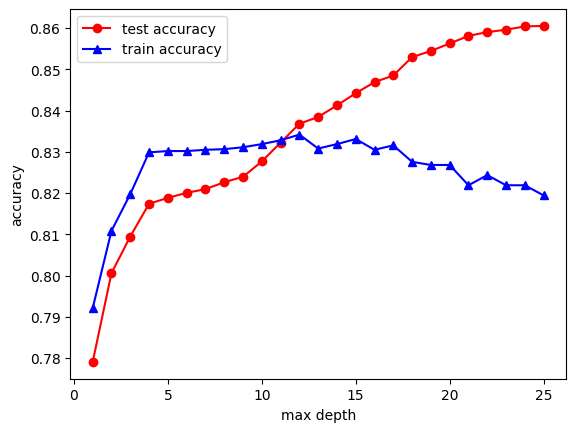

In [125]:
depths = range(1,26)
plt.plot(depths, accuracy_train, marker = "o", color = "red")
plt.plot(depths, accuracy_test, marker = "^", color = "blue")
plt.legend(['test accuracy', 'train accuracy'])
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.show()

<p style="font-size: 20px;"><b>Task 10</b></p>  
Refit the random forest model using the max_depth from above; save the feature importances in a dataframe. Sort the results and print the top five features.

In [126]:
best_rf = RandomForestClassifier(max_depth=best_depth)
best_rf.fit(x_train, y_train)
feature_imp_df = pd.DataFrame(zip(x_train.columns, best_rf.feature_importances_),  columns=['feature', 'importance'])
print('Top 5 random forest features:')
print(feature_imp_df.sort_values('importance', ascending=False).iloc[0:5])

Top 5 random forest features:
          feature  importance
1    capital-gain    0.369221
0             age    0.247698
3  hours-per-week    0.142474
2    capital-loss    0.139439
4        sex_Male    0.080169


# Create Additional Features and Re-Tune

<p style="font-size: 20px;"><b>Task 11</b></p>  
Looking at the education feature, there are 16 unique values – from preschool to professional school. Rather than adding dummy variables for each value, it makes sense to bin some of these values together. While there are many ways to do this, we will take the approach of combining the values into 3 groups: High school and less, College to Bachelors and Masters and more. Create a new column in df for this new feature called education_bin.


In [127]:
df["education_bin"] = pd.cut(df['education-num'], [0,9,13,16], labels=['HS or less', 'College to Bachelors', 'Masters or more'])

<p style="font-size: 20px;"><b>Task 12</b></p>  
Like we did previously, we will now add this new feature into our feature list and recreate X.


In [128]:
feature_cols = ['age',
       'capital-gain', 'capital-loss', 'hours-per-week', 'sex', 'race','education_bin']

In [129]:
x = df[feature_cols]

In [130]:
x = pd.get_dummies(df[feature_cols], drop_first=True)

<p style="font-size: 20px;"><b>Task 13</b></p>  
As we did before, we will tune the random forest classifier model by testing the performance over a range of max_depth values. Fit a random forest classifier for max_depth values from 1–25. Save the accuracy score for the train and test sets in the lists accuracy_train and accuracy_test.</


In [131]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=1, test_size=.2)

In [132]:
range_dephts = range(1, 26)
accuracy_train = []
accuracy_test = []

for i in range_dephts:
    rf = RandomForestClassifier(max_depth = i)
    rf.fit(x_train, y_train)
    accuracy_train.append(accuracy_score(y_train, rf.predict(x_train)))
    accuracy_test.append(accuracy_score(y_test, rf.predict(x_test)))

<p style="font-size: 20px;"><b>Task 14</b></p>  
Find the largest accuracy and the depth this occurs on the test data. Compare the results to the previously tuned model.


In [133]:
best_acc= np.max(accuracy_test)
best_depth = depths[np.argmax(accuracy_test)]
print(f'The highest accuracy on the test is achieved when depth: {best_depth}')
print(f'The highest accuracy on the test set is: {round(best_acc*100,3)}%')

The highest accuracy on the test is achieved when depth: 12
The highest accuracy on the test set is: 84.984%


<p style="font-size: 20px;"><b>Task 15</b></p>  
Plot the training and test accuracy of the models versus the max_depth. Compare the results from the previous model tuned.


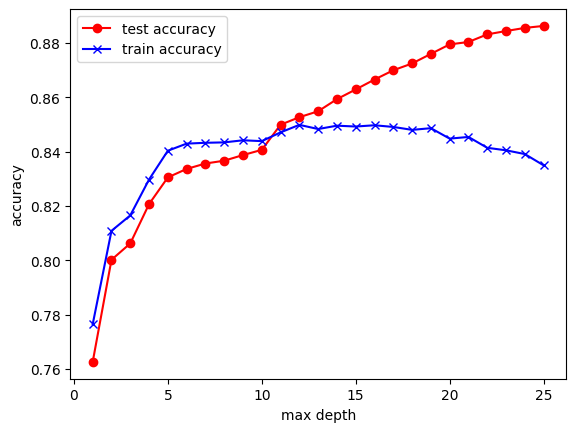

In [134]:
plt.plot(range_dephts, accuracy_train, color = "red", marker = "o")
plt.plot(range_dephts, accuracy_test, color = "blue", marker = "x")
plt.legend(['test accuracy', 'train accuracy'])
plt.xlabel('max depth')
plt.ylabel('accuracy')
plt.show()

<p style="font-size: 20px;"><b>Task 16</b></p>  
Refit the random forest model using the max_depth from above; save the feature importances in a dataframe. Sort the results and print the top five features. Compare the results from the previous model tuned.


In [136]:
best_rf = RandomForestClassifier(max_depth=best_depth)
best_rf.fit(x_train, y_train)
feature_imp_df_best = pd.DataFrame(zip(x_train.columns, best_rf.feature_importances_),  columns=['feature', 'importance'])
print('Top 5 random forest features:')
print(feature_imp_df_best.sort_values('importance', ascending=False).iloc[0:5])

Top 5 random forest features:
                          feature  importance
1                    capital-gain    0.309349
0                             age    0.211894
3                  hours-per-week    0.119862
10  education_bin_Masters or more    0.113342
2                    capital-loss    0.103356


In [137]:
print('Top 5 random forest features:')
print(feature_imp_df.sort_values('importance', ascending=False).iloc[0:5])

Top 5 random forest features:
          feature  importance
1    capital-gain    0.369221
0             age    0.247698
3  hours-per-week    0.142474
2    capital-loss    0.139439
4        sex_Male    0.080169
